# Phase 3 - Step 14: Organization-Wide Skill Gap Intelligence

This notebook aggregates missing skills across the entire enterprise workforce, calculates organizational deficiency percentages, and assigns criticality severity tiers.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

processed_dir = Path("data/processed")
df_gaps = pd.read_csv(processed_dir / "employee_skill_gaps.csv")

# Explode missing skills
all_missing = []
for idx, row in df_gaps.iterrows():
    if pd.notnull(row['missing_skills']) and row['missing_skills'].strip():
        skills = [s.strip() for s in row['missing_skills'].split(';') if s.strip()]
        for s in skills:
            all_missing.append({
                "department": row['department'],
                "job_role": row['job_role'],
                "missing_skill": s
            })

df_missing = pd.DataFrame(all_missing)
total_employees = len(df_gaps)

# Aggregate across organization
org_gaps = df_missing.groupby('missing_skill').agg(
    employees_missing=('missing_skill', 'count'),
    departments_affected=('department', 'nunique'),
    roles_affected=('job_role', 'nunique')
).reset_index()

org_gaps['percentage_missing'] = (org_gaps['employees_missing'] / total_employees * 100.0).round(2)

# Severity Classification:
# HIGH: > 15% of entire workforce or > 800 employees
# MEDIUM: 5% - 15% of workforce
# LOW: < 5% of workforce
def assign_severity(pct):
    if pct >= 12.0:
        return "HIGH"
    elif pct >= 6.0:
        return "MEDIUM"
    else:
        return "LOW"

org_gaps['severity'] = org_gaps['percentage_missing'].apply(assign_severity)
org_gaps = org_gaps.sort_values(by='employees_missing', ascending=False).reset_index(drop=True)

org_gaps.to_csv(processed_dir / "organization_skill_gaps.csv", index=False)
print(f"Saved organization_skill_gaps.csv ({len(org_gaps)} critical organizational skills).")
print(org_gaps.head(15))


Saved organization_skill_gaps.csv (105 critical organizational skills).
           missing_skill  employees_missing  departments_affected  \
0                  Excel                430                     2   
1                 Python                323                     1   
2                    Crm                258                     1   
3                    Sql                239                     3   
4       Google Analytics                218                     1   
5                    Seo                195                     1   
6               Power Bi                182                     2   
7       Client Retention                137                     1   
8       Crm (Salesforce)                137                     1   
9         Tax Compliance                136                     1   
10             Upselling                133                     1   
11  Financial Accounting                133                     1   
12  Contract Negotiation       

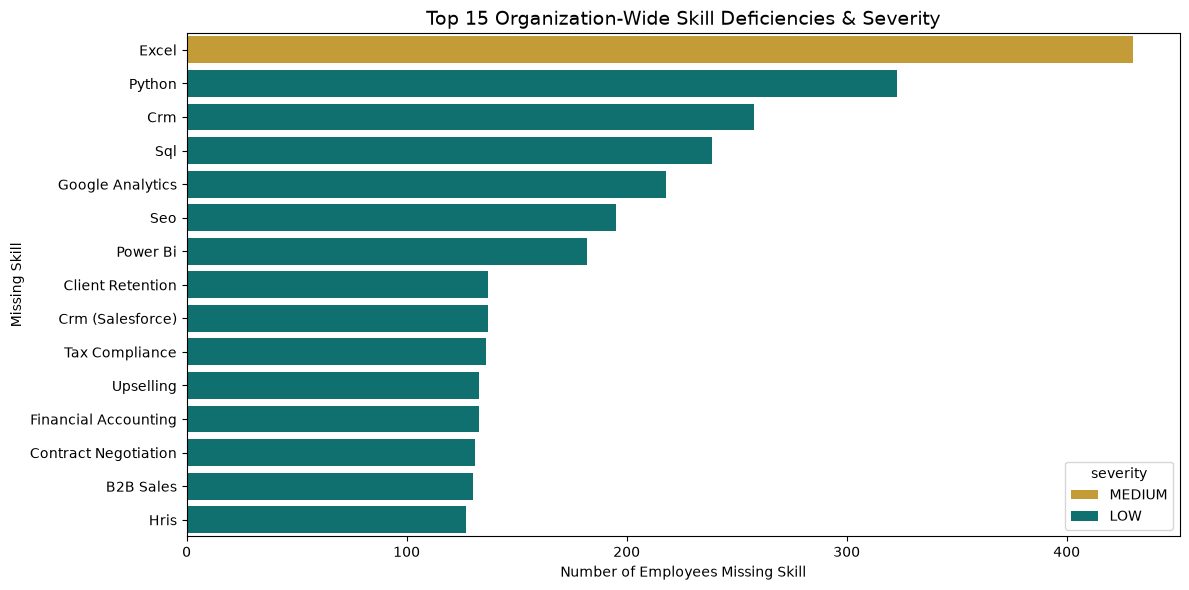

In [2]:
# Visualize Organization Skill Gaps
plt.figure(figsize=(12, 6))
top_15 = org_gaps.head(15)
sns.barplot(
    data=top_15,
    x='employees_missing',
    y='missing_skill',
    hue='severity',
    dodge=False,
    palette={'HIGH': 'crimson', 'MEDIUM': 'goldenrod', 'LOW': 'teal'}
)
plt.title("Top 15 Organization-Wide Skill Deficiencies & Severity", fontsize=14)
plt.xlabel("Number of Employees Missing Skill")
plt.ylabel("Missing Skill")
plt.tight_layout()
plt.show()
